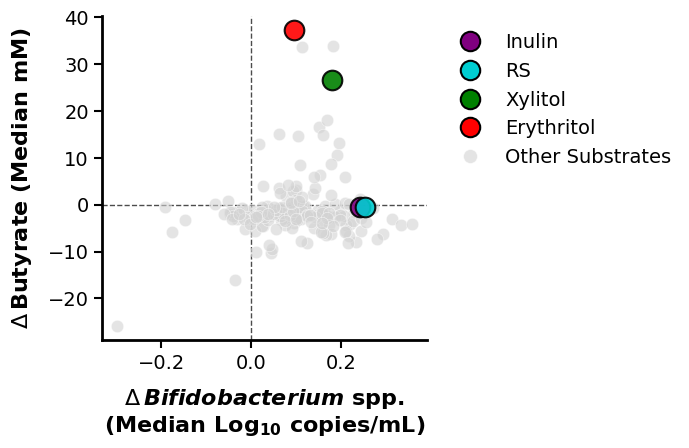

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# =============================================================================
# 1. Publication-Quality Visualization Settings (Nature Portfolio)
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

# Mathtext hack: Force \mathit to output bold-italic and \mathbf to output bold
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic:bold'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# =============================================================================
# 2. Robust Data Loading & Strict Exclusion Rules
# =============================================================================
def clean_and_convert_to_nan(df, cols, is_qpcr=False):
    """
    Strictly converts non-numeric values (e.g., 'Undetermined', '-', 'nan') to np.nan.
    Zero-imputation is completely avoided. Handles Excel scientific notation for qPCR.
    """
    for col in cols:
        s = df[col].astype(str).str.strip()
        s = s.replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', '', 'None'], np.nan)
        if is_qpcr:
            s = s.str.replace(r'\.E\+', 'E+', regex=True)
            s = s.str.replace(r'\.E\-', 'E-', regex=True)
        df[col] = pd.to_numeric(s, errors='coerce')
    return df

# Load raw datasets
df_buty = pd.read_csv('Butyrate(mM).csv')
df_bif = pd.read_csv('Bifidobacterium(qPCR).csv')

donor_cols = [c for c in df_buty.columns if c.startswith('HS-')]

# Apply data cleaning
df_buty = clean_and_convert_to_nan(df_buty, donor_cols, is_qpcr=False)
df_bif = clean_and_convert_to_nan(df_bif, donor_cols, is_qpcr=True)

# =============================================================================
# 3. Calculate Delta and Aggregate (Median) per Substrate
# =============================================================================
ctrl_buty = df_buty[df_buty['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0]
ctrl_bif = df_bif[df_bif['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0]

data = []
for k in df_buty['KULFFI'].dropna().unique():
    k_str = str(k).strip()
    if k_str in ['Control', 'Feces slurry'] or pd.isna(k):
        continue

    try:
        sub_buty = df_buty[df_buty['KULFFI'].str.strip() == k_str][donor_cols].iloc[0]
        sub_bif = df_bif[df_bif['KULFFI'].str.strip() == k_str][donor_cols].iloc[0]
    except:
        continue

    # Deltas (Bifidobacterium is Log10 transformed for absolute expansion dynamics)
    delta_buty = sub_buty - ctrl_buty
    delta_bif = np.log10(sub_bif + 1) - np.log10(ctrl_bif + 1)

    # Pairwise exclusion for valid correlation plotting
    valid_mask = pd.notna(delta_buty) & pd.notna(delta_bif)
    valid_delta_buty = delta_buty[valid_mask]
    valid_delta_bif = delta_bif[valid_mask]

    if len(valid_delta_buty) > 0:
        data.append({
            'KULFFI': k_str,
            'Delta_Bifido_Med': valid_delta_bif.median(),
            'Delta_Butyrate_Med': valid_delta_buty.median()
        })

df_plot = pd.DataFrame(data)

# =============================================================================
# 4. Plotting Figure 6a (Bifidobacterium Expansion vs Butyrate Production)
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 7))

target_substrates = ['Inulin', 'Resistant starch', 'Xylitol', 'Erythritol']

# Correct, unified color code based on Fig. 5a
highlights = {
    'Inulin': '#800080',             # Purple
    'Resistant starch': '#00CED1',   # Cyan
    'Xylitol': '#008000',            # Green
    'Erythritol': '#FF0000'          # Red
}

# 1. Other Substrates FIRST (Background)
df_other = df_plot[~df_plot['KULFFI'].isin(target_substrates)]
ax.scatter(df_other['Delta_Bifido_Med'], df_other['Delta_Butyrate_Med'],
           color='lightgray', alpha=0.6, s=80, edgecolors='white', linewidth=0.5, zorder=1)

# 2. Target Substrates LAST (Foreground)
for name, color in highlights.items():
    row = df_plot[df_plot['KULFFI'] == name]
    if len(row) > 0:
        x = row['Delta_Bifido_Med'].values[0]
        y = row['Delta_Butyrate_Med'].values[0]

        # Prevent exact overlapping of dots for Xylitol & Erythritol (from original @6a.ipynb)
        if name == 'Xylitol':
            x -= 0.005
            y += 0.8
        elif name == 'Erythritol':
            x += 0.005
            y -= 0.8

        ax.scatter(x, y, color=color, alpha=0.9, s=200, edgecolors='black', linewidth=1.5, zorder=3)

# Reference Lines (Zero-crossing)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=0)

# Axis Labels (with LaTeX thin space '\,')
ax.set_xlabel(r'$\Delta\,$$\mathit{Bifidobacterium}$ spp.' + '\n' + r'(Median Log$_{\mathbf{10}}$ copies/mL)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$\Delta\,$Butyrate (Median mM)', fontsize=16, fontweight='bold', labelpad=10)

ax.tick_params(axis='both', labelsize=14, width=1.5, length=6)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_box_aspect(1)

# Render strictly ordered legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Inulin', markerfacecolor=highlights['Inulin'], markersize=14, markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='RS', markerfacecolor=highlights['Resistant starch'], markersize=14, markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='Xylitol', markerfacecolor=highlights['Xylitol'], markersize=14, markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='Erythritol', markerfacecolor=highlights['Erythritol'], markersize=14, markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='Other Substrates', markerfacecolor='lightgray', markersize=10, markeredgecolor='white', markeredgewidth=0.5, alpha=0.6)
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False, fontsize=14)

plt.tight_layout()

# Export
output_file = 'Figure_6a.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')
plt.show()